In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import seaborn as sns

df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [9]:
df.drop(['deck', 'alive', 'class', 'who', 'adult_male', 'embark_town'], axis=1, inplace=True)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [10]:
df['age'].fillna(df['age'].median(), inplace=True)

df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df.isnull().sum()

/tmp/ipykernel_1474/1059996447.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_1474/1059996447.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
alone,0


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])

df['embarked'] = le.fit_transform(df['embarked'])

df['alone'] = le.fit_transform(df['alone'])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,0
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,2,1
3,1,1,0,35.0,1,0,53.1000,2,0
4,0,3,1,35.0,0,0,8.0500,2,1


In [12]:
df.dtypes

,0
survived,int64
pclass,int64
sex,int64
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,int64
alone,int64


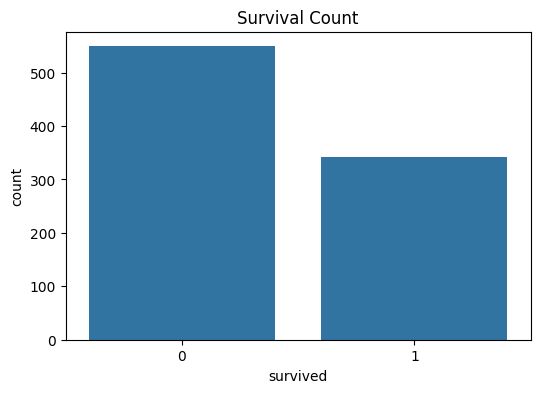

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='survived', data=df)

plt.title("Survival Count")

plt.show()

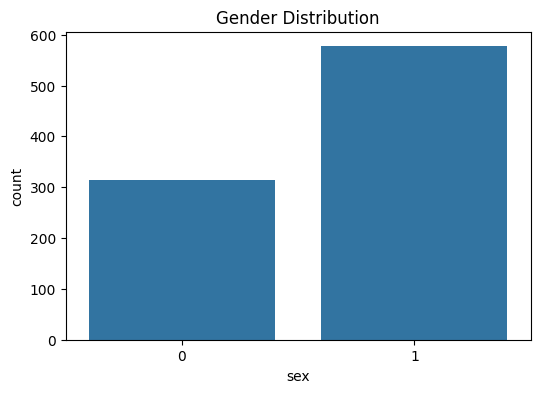

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")

plt.show()

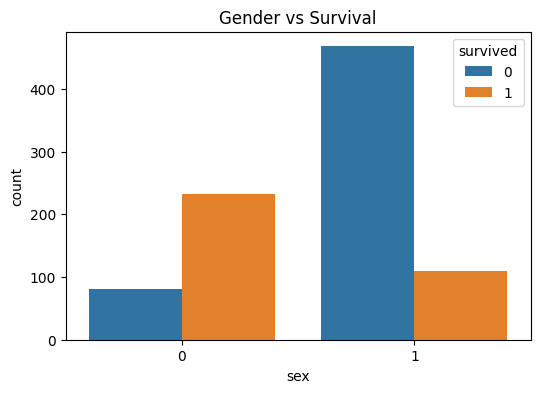

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', hue='survived', data=df)

plt.title("Gender vs Survival")

plt.show()

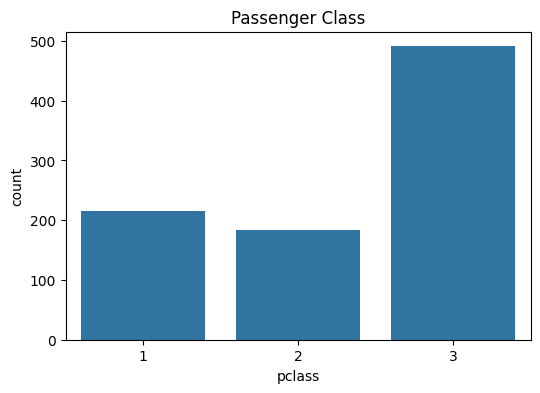

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='pclass', data=df)

plt.title("Passenger Class")

plt.show()

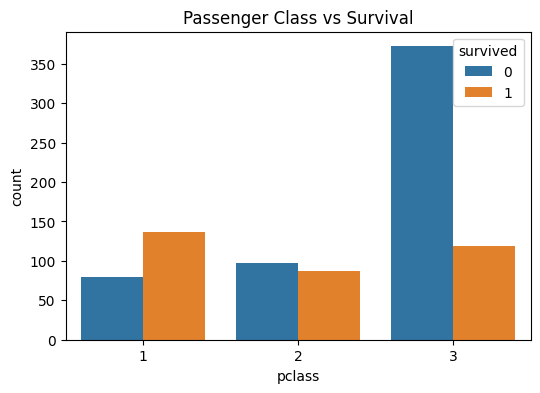

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='pclass', hue='survived', data=df)

plt.title("Passenger Class vs Survival")

plt.show()

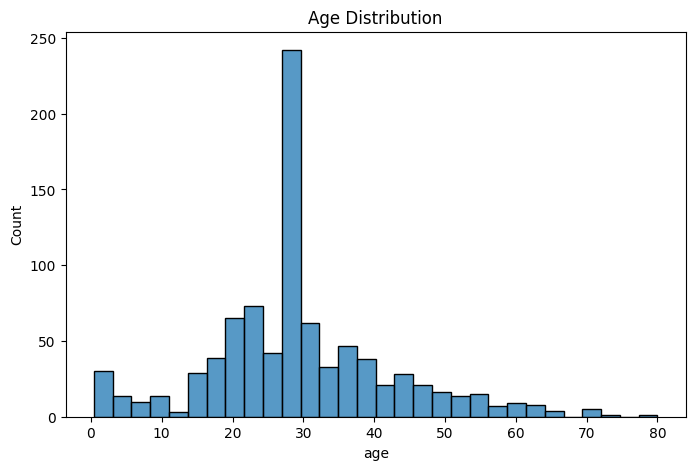

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30)

plt.title("Age Distribution")

plt.show()

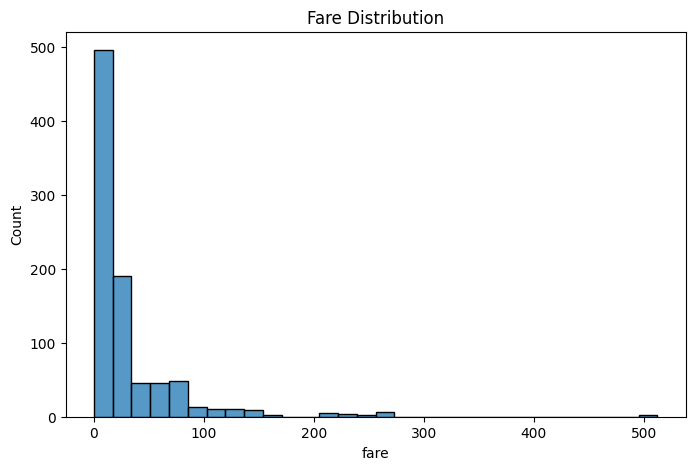

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['fare'], bins=30)

plt.title("Fare Distribution")

plt.show()

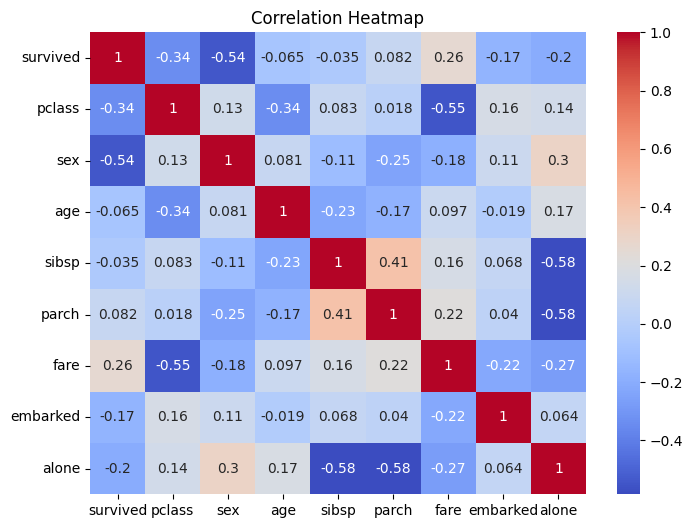

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

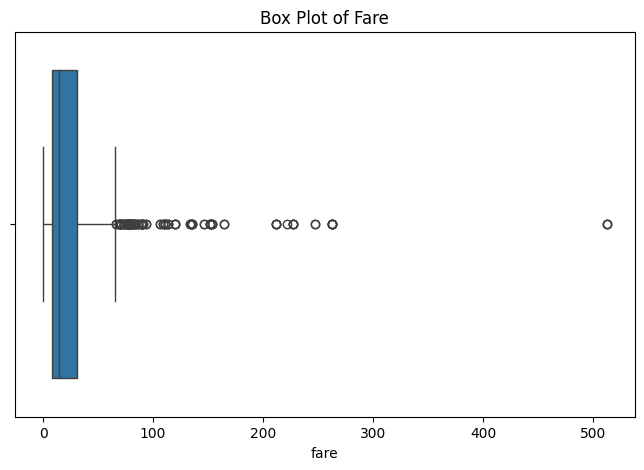

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['fare'])

plt.title("Box Plot of Fare")

plt.show()

In [23]:
X = df.drop('survived', axis=1)

y = df['survived']

print(X.head())

print(y.head())

   pclass  sex   age  sibsp  parch     fare  embarked  alone
0       3    1  22.0      1      0   7.2500         2      0
1       1    0  38.0      1      0  71.2833         0      0
2       3    0  26.0      0      0   7.9250         2      1
3       1    0  35.0      1      0  53.1000         2      0
4       3    1  35.0      0      0   8.0500         2      1
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)



Training Data: (712, 8)
Testing Data: (179, 8)


In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
model = LogisticRegression(max_iter=1000)

In [28]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [29]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[89 16]
 [20 54]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [33]:
print("Titanic Survival Prediction Project Completed Successfully!")

print("Model Accuracy:", accuracy)

Titanic Survival Prediction Project Completed Successfully!
Model Accuracy: 0.7988826815642458


In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
dt = DecisionTreeClassifier(random_state=42)

In [36]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
dt_pred = dt.predict(X_test)

print(dt_pred[:10])

[0 1 0 1 1 0 1 0 1 1]


In [38]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7821229050279329


In [39]:
dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[84 21]
 [18 56]]


In [40]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



In [41]:
print("Logistic Regression Accuracy :", accuracy)

print("Decision Tree Accuracy :", dt_accuracy)

Logistic Regression Accuracy : 0.7988826815642458
Decision Tree Accuracy : 0.7821229050279329


In [42]:
if accuracy > dt_accuracy:
    print("Logistic Regression performed better.")
elif dt_accuracy > accuracy:
    print("Decision Tree performed better.")
else:
    print("Both models have the same accuracy.")

Logistic Regression performed better.


In [43]:
print("----------- PROJECT SUMMARY -----------")

print("1. Dataset loaded successfully.")

print("2. Missing values handled.")

print("3. Categorical columns encoded.")

print("4. EDA completed using graphs.")

print("5. Logistic Regression model trained.")

print("6. Decision Tree model trained.")

print("7. Both models evaluated successfully.")

print("Project Completed Successfully!")



----------- PROJECT SUMMARY -----------
1. Dataset loaded successfully.
2. Missing values handled.
3. Categorical columns encoded.
4. EDA completed using graphs.
5. Logistic Regression model trained.
6. Decision Tree model trained.
7. Both models evaluated successfully.
Project Completed Successfully!
